In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## ⚠️ All ClinVar variants are manually annotated by the following splicing regions
# 🧬 Splicing-Related Genomic Regions

This document defines and names key genomic regions around splice sites, used for splicing-aware variant annotation and model interpretation.

> ⚠️ **All coordinate ranges are defined relative to the exon-intron boundary on the + strand.**
>
> For exons on the `-` strand, ranges must be **mirrored** accordingly:
> - Upstream becomes downstream
> - Start/end positions must be interpreted strand-aware
---
| Region Type  | Range (relative to exon-intron boundary on + strand) | Length (bp) | Notes                                      | Short Name    |
|-----------------------------------------------|------------------------------------------------------|-------------|-----------------------------------------------------------|---------------|
| **Canonical 5′ss**                            | `[+1, +2]` (intronic)                                | 2 bp        | Core GT splice site                                       | `5ss_can`     |
| **5′ss intronic proximal**                    | `[+3, +6]` (intronic)                                | 4 bp        | Extended donor consensus                                  | `5ss_iprox`   |
| **5′ss exonic proximal**                      | `[-3, 0]` (exonic)                                   | 3 bp        | Extended donor consensus                      | `5ss_eprox`   |
| **Canonical 3′ss**                            | `[-2, -1]` (intronic)                                | 2 bp        | Core AG splice site                                       | `3ss_can`     |
| **3′ss intronic proximal**                    | `[-17, -3]` (intronic)                               | 15 bp       | Polypyrimidine tract and branchpoint proximity            | `3ss_iprox`   |
| **Branchpoint region**                        | `[-40, -18]` (intronic)                              | 23 bp       | Typical location of lariat-forming branchpoint            | `bp_region`   |
| **3′ss exonic proximal**                      | `[0, +3]` (exonic)                                   | 3 bp        | Extended acceptor consensus                   | `3ss_eprox`   |
| **Exon body excluding 5′ss/3′ss proximal**     | Exon excluding `[-3, +3]` at both ends               | Varies      | Coding region with reduced direct splice regulatory input | `exon_core`   |
---


## 🔖 Notes:

- Ranges are given in **relative coordinates** and must be computed with respect to strand.
- In genomic coordinate systems:
  - For `+` strand exons: ranges apply as shown.
  - For `−` strand exons: ranges must be flipped accordingly, and applied to exon **start** instead of **end** (and vice versa).
- All short names are designed to be used in:
  - BED files (`feature` column)
  - Annotation labels

In [66]:
# Import ClinVar variants downloaded from ftp site and annotated manually for splicing regions
clinvar_file = "./clinvar_hg38/clinvar_anno.vcf"
clinvar_df = pd.read_csv(clinvar_file, comment='#', delimiter='\t', header=None)
clinvar_df.columns = ["chr", "pos", "clinvar_id", "ref", "alt", "qual", "filter", "info", 
                      "3ss_can", "3ss_eprox", "3ss_iprox", "bp_region", "5ss_can", "5ss_eprox", "5ss_iprox", "exon_core"]

# Import downloaded SpliceVarDB variants 
svdb_file = "./splicevardb_hg38/splicevardb.download.tsv"
svdb_df = pd.read_csv(svdb_file, sep="\t")
svdb_df.rename(columns={'variant_id':'svdb_id', 'classification':'spliceogenicity'}, inplace=True)
# Split the hg38 column into four new columns
split_cols = svdb_df['hg38'].str.split('-', expand=True)
split_cols.columns = ['chr', 'pos', 'ref', 'alt']
split_cols['pos'] = split_cols['pos'].astype(int)
split_cols['chr'] = split_cols['chr'].apply(lambda x: f"chr{x}")
svdb_df = pd.concat([svdb_df, split_cols], axis=1)
svdb_df = svdb_df.drop(['hg19', 'hg38'], axis=1)

# Take the intersection between ClinVar and SpliceVarDB
# 10034 variants present in both databases
intersect_df = clinvar_df.merge(svdb_df, on=['chr', 'pos', 'ref', 'alt'], how='inner')
cols_to_binarize = ['3ss_can', '3ss_eprox', '3ss_iprox', 'bp_region', 
                    '5ss_can', '5ss_eprox', '5ss_iprox', 'exon_core']
# Convert each column to binary: 1 if > 0, else 0
intersect_df[cols_to_binarize] = intersect_df[cols_to_binarize].gt(0).astype(int)
intersect_df

,chr,pos,clinvar_id,ref,alt,qual,filter,info,3ss_can,3ss_eprox,...,5ss_eprox,5ss_iprox,exon_core,svdb_id,gene,hgvs,method,spliceogenicity,location,doi
0,chr1,1049450,578463,G,A,.,.,AF_ESP=0.00008;AF_EXAC=0.00005;ALLELEID=556536...,0.0,0.0,...,3.0,0.0,0.0,239,AGRN,NM_198576.4:c.4513G>A,RNA-Seq,Splice-altering,Exonic,10.1101/gr.231951.117
1,chr1,1051638,937626,C,T,.,.,AF_EXAC=0.00002;ALLELEID=929929;CLNDISDB=MONDO...,0.0,0.0,...,0.0,0.0,3.0,242,AGRN,NM_198576.4:c.5556C>T,RNA-Seq,Splice-altering,Exonic,10.1101/gr.231951.117
2,chr1,3244069,2912989,C,T,.,.,"ALLELEID=3079030;CLNDISDB=MONDO:MONDO:0014152,...",0.0,0.0,...,0.0,0.0,0.0,2969,PRDM16,NM_022114.4:c.388-18C>T,MFASS,Normal,Intronic,10.1016/j.molcel.2018.10.037
3,chr1,3244097,451127,C,T,.,.,AF_EXAC=0.00006;AF_TGP=0.00020;ALLELEID=442821...,0.0,0.0,...,0.0,0.0,4.0,2971,PRDM16,NM_022114.4:c.398C>T,MFASS,Normal,Exonic,10.1016/j.molcel.2018.10.037
4,chr1,3244101,1607498,C,T,.,.,AF_EXAC=0.00002;ALLELEID=1572808;CLNDISDB=MOND...,0.0,0.0,...,0.0,0.0,4.0,2972,PRDM16,NM_022114.4:c.402C>T,MFASS,Normal,Exonic,10.1016/j.molcel.2018.10.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10029,chrX,154987257,1330896,A,C,.,.,"ALLELEID=1321573;CLNDISDB=MONDO:MONDO:0010602,...",0.0,0.0,...,0.0,0.0,1.0,50325,F8,NM_000132.4:c.650T>G,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"
10030,chrX,154987267,993937,A,C,.,.,"ALLELEID=982329;CLNDISDB=MONDO:MONDO:0010602,M...",0.0,0.0,...,0.0,0.0,1.0,50328,F8,NM_000132.4:c.640T>G,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"
10031,chrX,154987301,811454,A,C,.,.,"ALLELEID=800295;CLNDISDB=MONDO:MONDO:0010602,M...",0.0,0.0,...,0.0,0.0,1.0,50331,F8,NM_000132.4:c.606T>G,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"
10032,chrX,154987302,804142,C,T,.,.,"ALLELEID=792181;CLNDISDB=MONDO:MONDO:0010602,M...",0.0,0.0,...,0.0,0.0,1.0,50332,F8,NM_000132.4:c.605G>A,MaPSy,Low-frequency,Exonic,"10.1038/ng.3837,10.1038/ng.3837"


# ClinVar Features Documentation
### `This info is contained in the header of clinvar.vcf`
Download link: https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/
## Basic Variant Information
| Feature | Description |
|---------|-------------|
| **CLNHGVS** | Top-level (primary assembly, alt, or patch) HGVS expression. |
| **GENEINFO** | Gene(s) for the variant reported as gene symbol:gene id. The gene symbol and id are delimited by a colon (:) and each pair is delimited by a vertical bar (\|). |
| **CLNVC** | Variant type. |
| **CLNVCSO** | Sequence Ontology id for variant type. |
| **MC** | Comma separated list of molecular consequence in the form of Sequence Ontology ID\|molecular_consequence. |
| **ORIGIN** | Allele origin. One or more of the following values may be added: 0 - unknown; 1 - germline; 2 - somatic; 4 - inherited; 8 - paternal; 16 - maternal; 32 - de-novo; 64 - biparental; 128 - uniparental; 256 - not-tested; 512 - tested-inconclusive; 1073741824 - other. |

## Germline Classification Information
| Feature | Description |
|---------|-------------|
| **CLNSIG** | Aggregate germline classification for this single variant; multiple values are separated by a vertical bar. |
| **CLNDN** | ClinVar's preferred disease name for the concept specified by disease identifiers in CLNDISDB. |
| **CLNDISDB** | Tag-value pairs of disease database name and identifier submitted for germline classifications, e.g. OMIM:NNNNNN. |
| **CLNREVSTAT** | ClinVar review status of germline classification for the Variation ID. |
| **CLNSIGCONF** | Conflicting germline classification for this single variant; multiple values are separated by a vertical bar. |

## Oncogenicity Classification Information
| Feature | Description |
|---------|-------------|
| **ONC** | Aggregate oncogenicity classification for this single variant; multiple values are separated by a vertical bar. |
| **ONCDN** | ClinVar's preferred disease name for the concept specified by disease identifiers in ONCDISDB. |
| **ONCDISDB** | Tag-value pairs of disease database name and identifier submitted for oncogenicity classifications, e.g. MedGen:NNNNNN. |
| **ONCREVSTAT** | ClinVar review status of oncogenicity classification for the Variation ID. |
| **ONCCONF** | Conflicting oncogenicity classification for this single variant; multiple values are separated by a vertical bar. |

## Somatic Clinical Impact Information
| Feature | Description |
|---------|-------------|
| **SCI** | Aggregate somatic clinical impact for this single variant; multiple values are separated by a vertical bar. |
| **SCIDN** | ClinVar's preferred disease name for the concept specified by disease identifiers in SCIDISDB. |
| **SCIDISDB** | Tag-value pairs of disease database name and identifier submitted for somatic clinical impact classifications, e.g. MedGen:NNNNNN. |
| **SCIREVSTAT** | ClinVar review status of somatic clinical impact for the Variation ID. |


## ⭐ ClinVar Review Status Levels

ClinVar assigns a **star rating system** to indicate the confidence level in the review of a variant's classification.
Info link: https://www.ncbi.nlm.nih.gov/clinvar/docs/review_status/
| ⭐ Stars | Review Status                                              | Description                                                                                                                                           |
|---------|------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------|
| 4   | **practice guideline**                                      | There is a submitted record with a classification from a practice guideline.                                                                         |
| 3    | **reviewed by expert panel**                                | There is a submitted record with a classification from an expert panel.                                                                              |
| 2     | **criteria provided, multiple submitters, no conflicts**    | There are multiple submitted records with a classification. Assertion criteria and evidence were provided and the classifications agree.             |
| 1     | **criteria provided, conflicting classifications**          | There are multiple submitted records with classifications, but they conflict. Assertion criteria and evidence were provided.                         |
| 1    | **criteria provided, single submitter**                     | There is a single submitted record with a classification, where assertion criteria and evidence were provided.                                       |
| 0    | **no assertion criteria provided**                          | One or more submitted records have classifications but lack assertion criteria and evidence.                                                          |
| 0   | **no classification provided**                              | One or more submitted records lack a classification entirely.                                                                                         |
| 0   | **no classification for the individual variant**           | The variant was only submitted as part of a haplotype or genotype, and was not classified individually.                                               |

> **Note:** Star ratings can be used as a proxy for the strength and trustworthiness of clinical interpretations in ClinVar.


In [70]:
# Extract information from ClinVar.vcf INFO column
def extract_vcf_info_fields_regex(df, field_names):
    """
    Extract fields from ClinVar 'info' column using regex.
    
    Args:
    -----------
    df : pandas.DataFrame
        DataFrame containing VCF data with an 'info' column
    field_names : list
        List of field names to extract from the 'info' column
        
    Returns:
    --------
    pandas.DataFrame
        Input DataFrame with added columns for each extracted field
    """
    result_df = df.copy()
    
    for field in field_names:
        # Create a regex pattern that specifically targets the field
        pattern = r'(?:^|;)' + field + r'=([^;]+)'
        result_df[field] = df['info'].str.extract(pattern, expand=False)
    
    return result_df
    
feature_list = ["CLNHGVS", "GENEINFO", "AF_EXAC",
                "CLNSIG", "CLNDN", "CLNDISDB", "CLNREVSTAT", "CLNSIGCONF", "CLNVC", "CLNVCSO", "MC", 
                "ONC", "ONCDN", "ONCDISDB", "ONCREVSTAT", "ONCCONF", "ORIGIN",
                "SCI", "SCIDN", "SCIDISDB", "SCIREVSTAT"]

intersect_df = extract_vcf_info_fields_regex(intersect_df, feature_list) 

In [ ]:
# Filter for variants with valid pathogenicity/oncogenicity/somatic impact labels
patho_labels = ['Likely_benign', 'Benign/Likely_benign', 'Benign', 
                'Uncertain_significance',
                'Likely_pathogenic', 'Pathogenic', 'Pathogenic/Likely_pathogenic']

onc_labels = ['Likely_oncogenic', 'Oncogenic', 'Uncertain_significance', 'no_classification_for_the_single_variant']

sci_labels = ['no_classification_for_the_single_variant',
              'Tier_IV_-_Benign/Likely_benign', 'Tier_III_-_Unknown','Tier_II_-_Potential','Tier_I_-_Strong']

# Drop variants with 'Conflicting' spliceogenicity classification from SpliceVarDB
spliceogenicity_labels = ['Low-frequency', 'Splice-altering', 'Normal']

# Filter based on any of the classification labels AND valid spliceogenicity
label_mask = (
    intersect_df['CLNSIG'].isin(patho_labels) |
    intersect_df['ONC'].isin(onc_labels) |
    intersect_df['SCI'].isin(sci_labels)
)

splice_mask = intersect_df['spliceogenicity'].isin(spliceogenicity_labels)

filtered_intersect_df = intersect_df[label_mask & splice_mask].reset_index(drop=True)

In [91]:
# Create simplified labels for CLNSIG, ONC, SCI, and CLNREVSTAT
patho_class_map = {
    'Pathogenic': 'pathogenic',
    'Likely_pathogenic': 'pathogenic',
    'Pathogenic/Likely_pathogenic': 'pathogenic',
    'Uncertain_significance': 'vus',
    'Benign': 'benign',
    'Likely_benign': 'benign',
    'Benign/Likely_benign': 'benign',
}

onc_class_map = {
    'Oncogenic': 'pathogenic',
    'Likely_oncogenic': 'pathogenic',
    'Uncertain_significance': 'vus',
    'no_classification_for_the_single_variant': 'vus',  # default to VUS due to uncertainty
}

sci_class_map = {
    'Tier_I_-_Strong': 'pathogenic',
    'Tier_II_-_Potential': 'pathogenic',
    'Tier_III_-_Unknown': 'vus',
    'Tier_IV_-_Benign/Likely_benign': 'benign',
    'no_classification_for_the_single_variant': 'vus',  # safest assumption in absence of data
}

clinvar_star_rating = {
    'practice_guideline': 4,
    'reviewed_by_expert_panel': 3,
    'criteria_provided,_multiple_submitters,_no_conflicts': 2,
    'criteria_provided,_conflicting_classifications': 1,
    'criteria_provided,_single_submitter': 1,
    'no_assertion_criteria_provided': 0,
    'no_classification_provided': 0,
    'no_classification_for_the_single_variant': 0,
    'no_classifications_from_unflagged_records': 0,
    np.nan: 0  # Treat NaN as no stars
}

filtered_intersect_df['CLNSIG_simplified'] = filtered_intersect_df['CLNSIG'].map(patho_class_map)
filtered_intersect_df['ONC_simplified'] = filtered_intersect_df['ONC'].map(onc_class_map)
filtered_intersect_df['SCI_simplified'] = filtered_intersect_df['SCI'].map(sci_class_map)
filtered_intersect_df['CLNREVSTAT'] = filtered_intersect_df['CLNREVSTAT'].map(clinvar_star_rating).fillna(0).astype(int)

🧬 VARIANT DATA SUMMARY REPORT

🔹 BASIC INFO
  • Total number of variants: 8603
  • Total number of unique genes: 1848

🔹 DISTRIBUTION: VARIANTS PER GENE
count    1848.000000
mean        4.655303
std        12.953614
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       319.000000


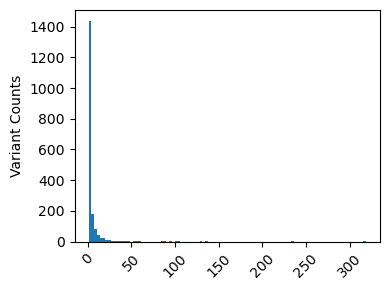

Top 5 genes with most variants: BRCA1, BRCA2, NF1, COL1A2, COL7A1

🔹 DISTRIBUTION: VARIANT TYPE
                           Count  Proportion
single_nucleotide_variant   8499    0.987911
Deletion                      71    0.008253
Microsatellite                17    0.001976
Duplication                    9    0.001046
Indel                          6    0.000697
Insertion                      1    0.000116

🔹 DISTRIBUTION: SPLICEOGENICITY LABELS
                 Count  Proportion
Low-frequency     5188    0.603045
Normal            1956    0.227363
Splice-altering   1459    0.169592

🔹 DISTRIBUTION: GENOMIC LOCATIONS
                 Count  Proportion
Exonic            6213    0.722190
Intronic          2239    0.260258
Exonic,Intronic    151    0.017552

🔹 DISTRIBUTION: EXPERIMENTAL METHODS
                               Count  Proportion
MFASS                           3905    0.453911
MaPSy                           2872    0.333837
RNA-Seq                          587    0.068232


In [97]:
def summarize_variant_data(df):
    print("="*70)
    print("🧬 VARIANT DATA SUMMARY REPORT")
    print("="*70)

    # 1. Basic summary
    print("\n🔹 BASIC INFO")
    print(f"  • Total number of variants: {len(df)}")
    print(f"  • Total number of unique genes: {df['gene'].nunique()}")
    print("="*70)
    
    # 2. Variants per gene
    print("\n🔹 DISTRIBUTION: VARIANTS PER GENE")
    variants_per_gene = df['gene'].value_counts()
    print(variants_per_gene.describe().to_string())

    plt.figure(figsize=(4, 3))
    plt.hist(variants_per_gene.values, bins=100)
    plt.ylabel('Variant Counts')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    top_genes = variants_per_gene.head(5)
    print(f"Top 5 genes with most variants: {', '.join(top_genes.index)}")
    print("="*70)
    
    # 3. Variant type
    print("\n🔹 DISTRIBUTION: VARIANT TYPE")
    variant_type_dist = df['CLNVC'].value_counts()
    print(variant_type_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 4. Spliceogenicity
    print("\n🔹 DISTRIBUTION: SPLICEOGENICITY LABELS")
    splice_dist = df['spliceogenicity'].value_counts()
    print(splice_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 5. Genomic location
    print("\n🔹 DISTRIBUTION: GENOMIC LOCATIONS")
    location_dist = df['location'].value_counts()
    print(location_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 6. Experimental methods
    print("\n🔹 DISTRIBUTION: EXPERIMENTAL METHODS")
    method_dist = df['method'].value_counts()
    print(method_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)

    # 7. ClinVar Review Status
    print("\n🔹 DISTRIBUTION: CLINVAR REVIEW STATUS")
    revstat_dist = df['CLNREVSTAT'].value_counts()
    print(revstat_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 7. ClinVar simplified classification
    print("\n🔹 DISTRIBUTION: CLINVAR GERMLINE PATHOGENICITY CLASSIFICATION (CLNSIG_simplified)")
    patho_dist = df['CLNSIG_simplified'].value_counts()
    #print(patho_dist.to_string())
    print(patho_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 8. Oncogenic simplified classification
    print("\n🔹 DISTRIBUTION: ONCOGENICITY (ONC_simplified)")
    onc_dist = df['ONC_simplified'].value_counts()
    #print(onc_dist.to_string())
    print(onc_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 9. Scientific evidence simplified classification
    print("\n🔹 DISTRIBUTION: SOMATIC CLINICAL IMPACT CLASSIFICATION (SCI_simplified)")
    sci_dist = df['SCI_simplified'].value_counts()
    #print(sci_dist.to_string())
    print(sci_dist.to_frame('Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # 10. Cross-tab: Spliceogenicity vs CLNSIG_simplified
    print("\n🔹 Stratified: SPLICEOGENICITY × CLNSIG_simplified")
    cross_tab = pd.crosstab(df['spliceogenicity'], df['CLNSIG_simplified'], margins=True)
    print(cross_tab.to_string())
    print("="*70)
    
    print("\n📉 Missing value summary:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print("="*70)
    
    # 11. Binary region summary
    binary_cols = ['3ss_can', '3ss_eprox', '3ss_iprox', 'bp_region',
                   '5ss_can', '5ss_eprox', '5ss_iprox', 'exon_core']

    print("\n🔹 REGULATORY REGION BINARY COUNTS")

    # Overall sum of region counts
    region_counts = df[binary_cols].sum().sort_values(ascending=False)
    print("\n🧮 Total region hits across all variants:")
    print(region_counts.to_frame(name='Count').assign(Proportion=lambda x: x['Count'] / len(df)))
    print("="*70)
    
    # Cross-tab with spliceogenicity
    print("\n📊 Spliceogenicity × Region")
    splicing_region_ct = df.groupby("spliceogenicity")[binary_cols].sum()
    print(splicing_region_ct)
    print("="*70)
    
    # Cross-tab with pathogenicity
    print("\n📊 CLNSIG_simplified × Region")
    patho_region_ct = df.groupby("CLNSIG_simplified")[binary_cols].sum()
    print(patho_region_ct)
    # Optional: export to CSV
    # cross_tab.to_csv("cross_tab_spliceogenicity_CLNSIG.csv")
    print("="*70)
    # Triple-level conditional summary (raw counts)
    print("\n📊 Spliceogenicity × CLNSIG_simplified × Region (raw counts of hits = 1)")
    triple_region_counts = (
        df
        .groupby(['spliceogenicity', 'CLNSIG_simplified'])[binary_cols]
        .sum()
        .astype(int)
    )
    print(triple_region_counts)
    print("="*70)
    
summarize_variant_data(filtered_intersect_df)
